In [6]:
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [8]:
fashin_mnist=keras.datasets.fashion_mnist
(x_train,y_train),(x_test,y_test)=fashin_mnist.load_data()

4422102/4422102 [==============================] - 12s 3us/step


In [9]:
x_train.shape

(60000, 28, 28)

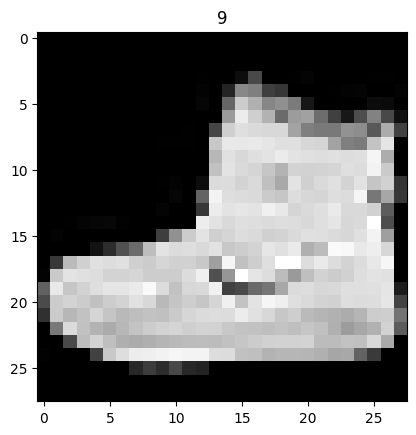

In [10]:
plt.imshow(x_train[0], cmap='gray')
plt.title(y_train[0])
plt.show()

In [12]:
#noramlize data
x_train = x_train / 255.0
x_test = x_test / 255.0

In [13]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [14]:
model = keras.Sequential([
    
    # First Convolution Layer
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    
    # Pooling Layer
    layers.MaxPooling2D((2,2)),
    
    # Second Convolution Layer
    layers.Conv2D(64, (3,3), activation='relu'),
    
    # Second Pooling
    layers.MaxPooling2D((2,2)),
    
    # Flatten Layer
    layers.Flatten(),
    
    # Dense Layer
    layers.Dense(128, activation='relu'),
    
    # Output Layer
    layers.Dense(10, activation='softmax')
])

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 [==============================] - 83s 42ms/step - loss: 0.4492 - accuracy: 0.8367 - val_loss: 0.3479 - val_accuracy: 0.8744
Epoch 2/10
1875/1875 [==============================] - 77s 41ms/step - loss: 0.2985 - accuracy: 0.8909 - val_loss: 0.3028 - val_accuracy: 0.8882
Epoch 3/10
1875/1875 [==============================] - 75s 40ms/step - loss: 0.2534 - accuracy: 0.9054 - val_loss: 0.2972 - val_accuracy: 0.8912
Epoch 4/10
1875/1875 [==============================] - 74s 39ms/step - loss: 0.2216 - accuracy: 0.9177 - val_loss: 0.2697 - val_accuracy: 0.9013
Epoch 5/10
1875/1875 [==============================] - 70s 38ms/step - loss: 0.1967 - accuracy: 0.9271 - val_loss: 0.2659 - val_accuracy: 0.9058
Epoch 6/10
1875/1875 [==============================] - 81s 43ms/step - loss: 0.1755 - accuracy: 0.9339 - val_loss: 0.2663 - val_accuracy: 0.9035
Epoch 7/10
1875/1875 [==============================] - 87s 47ms/step - loss: 0.1538 - accuracy: 0.9423 - val_loss: 0.2708 -

In [17]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 [==============================] - 5s 16ms/step - loss: 0.2988 - accuracy: 0.9094
Test Accuracy: 0.9093999862670898


In [18]:
predictions = model.predict(x_test)

import numpy as np

print("Predicted Class:", np.argmax(predictions[0]))
print("Actual Class:", y_test[0])

313/313 [==============================] - 6s 14ms/step
Predicted Class: 9
Actual Class: 9
